In [1]:
!pip install -q transformers>=4.35.0 datasets>=2.14.0 seqeval>=1.2.2 pytorch-crf>=0.7.2 accelerate>=0.24.0 scikit-learn>=1.3.0 matplotlib>=3.7.0 pandas>=2.0.0 nervaluate
print("All dependencies installed!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [ ]:
import os, torch
DATASET_TYPE = "ekstep"
MODEL_TYPE = "full"
USE_CONTEXT_WINDOW = False
CONTEXT_WINDOW_SIZE = 3
NUM_FOLDS = 1 
ENCODER_NAME = "evolawyer/inlegalbert-sc-ner-silver"
MAX_SEQ_LENGTH = 512         
LSTM_HIDDEN = 256
LSTM_LAYERS = 1
DROPOUT = 0.3
ENCODER_LR = 2e-5
HEAD_LR = 1e-3
BATCH_SIZE = 8
GRADIENT_ACCUMULATION = 2
EPOCHS = 5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
FREEZE_ENCODER_EPOCHS = 1
EARLY_STOPPING_PATIENCE = 2
SEED = 42
SAVE_DIR = "/kaggle/working/SAIL_NER"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Config loaded. Dataset: {DATASET_TYPE} | Model: {MODEL_TYPE} | Context window: {USE_CONTEXT_WINDOW}")
print(f"Save directory: {SAVE_DIR}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Config loaded. Dataset: ekstep | Model: full | Context window: False
Save directory: /kaggle/working/SAIL_NER
GPU available: True
GPU: Tesla T4


In [ ]:

if DATASET_TYPE == "il-tur":
    ENTITY_TYPES = ["APP", "RESP", "A.COUNSEL", "R.COUNSEL", "JUDGE", "WIT", "AUTH", "COURT", "STAT", "PREC", "DATE", "CASENO"]
else:
    ENTITY_TYPES = [
        "COURT", "PETITIONER", "RESPONDENT", "JUDGE", "LAWYER",
        "DATE", "ORG", "GPE", "STATUTE", "PROVISION",
        "PRECEDENT", "CASE_NUMBER", "WITNESS", "OTHER_PERSON"
    ]
LABEL_LIST = ["O"]
for ent in ENTITY_TYPES:
    LABEL_LIST.append(f"B-{ent}")
    LABEL_LIST.append(f"I-{ent}")

LABEL2ID = {label: i for i, label in enumerate(LABEL_LIST)}
ID2LABEL = {i: label for i, label in enumerate(LABEL_LIST)}
NUM_LABELS = len(LABEL_LIST)
print(f"Dataset Scheme: {DATASET_TYPE.upper()}")
print(f"Number of Entities: {len(ENTITY_TYPES)}")
print(f"Number of BIO Labels: {NUM_LABELS}")

Dataset Scheme: EKSTEP
Number of Entities: 14
Number of BIO Labels: 29


In [5]:
import json, zipfile, requests

DATA_DIR = os.path.join(SAVE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

if DATASET_TYPE == "ekstep":
    URLS = {
        "train": "https://storage.googleapis.com/indianlegalbert/OPEN_SOURCED_FILES/NER/NER_TRAIN.zip",
        "dev":   "https://storage.googleapis.com/indianlegalbert/OPEN_SOURCED_FILES/NER/NER_DEV.zip",
        "test":  "https://storage.googleapis.com/indianlegalbert/OPEN_SOURCED_FILES/NER/NER_TEST.zip",
    }

    def download_and_extract(url, name, data_dir):
        zip_path = os.path.join(data_dir, f"{name}.zip")
        extract_dir = os.path.join(data_dir, name)
        if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
            print(f"  {name} already exists, skipping.")
            return extract_dir
        print(f"  Downloading {name}...")
        r = requests.get(url, stream=True); r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)
        print(f"  Extracting {name}...")
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)
        os.remove(zip_path)
        return extract_dir

    for split, url in URLS.items():
        download_and_extract(url, split, DATA_DIR)
    print("EkStep data loaded.")
else:
    LOCAL_IL_TUR_DIR = None
    candidates = [
        "./IL-TUR/dataset",
        "../IL-TUR/dataset",
        "./dataset",
        "c:/Users/koppa/OneDrive/Documents/surge 2026/IL-TUR/dataset",
        "/kaggle/input/il-tur/dataset",
        "/content/IL-TUR/dataset"
    ]
    for c in candidates:
        if os.path.exists(c):
            LOCAL_IL_TUR_DIR = c
            break
            
    if LOCAL_IL_TUR_DIR:
        print(f"Found local IL-TUR dataset at: {LOCAL_IL_TUR_DIR}")
        DATA_DIR = LOCAL_IL_TUR_DIR
    else:
        print("WARNING: Local IL-TUR dataset directory not found. Please upload it or double-check paths.")

  Extracting train...
  Extracting dev...
  Extracting test...
EkStep data loaded.


In [13]:

import re

def find_json_files(directory):
    json_files = []
    for root, dirs, files in os.walk(directory):
        for f in files:
            if f.endswith(".json"):
                json_files.append(os.path.join(root, f))
    return sorted(json_files)

def parse_spacy_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    documents = []
    if isinstance(data, dict):
        data = [data]
    for doc in data:
        if "annotations" in doc and "data" in doc and isinstance(doc["data"], dict) and "text" in doc["data"]:
            text = doc["data"]["text"]
            spans = []
            for annot in doc.get("annotations", []):
                for res in annot.get("result", []):
                    if res.get("type") == "labels":
                        val = res.get("value", {})
                        start = val.get("start")
                        end = val.get("end")
                        labels = val.get("labels", [])
                        ent_text = val.get("text", "")
                        if labels and start is not None and end is not None:
                            spans.append((start, end, labels[0], ent_text))
            words, labels = align_char_labels_to_words(text, spans)
            sentences = split_document_into_sentences(words, labels)
            documents.append(sentences)
        else:
            doc_sentences = []
            paragraphs = doc.get("paragraphs", doc.get("annotations", []))
            if not paragraphs and "sentences" in doc:
                paragraphs = [doc]
            for para in paragraphs:
                sentences = para.get("sentences", [])
                if not sentences:
                    tokens = para.get("tokens", [])
                    if tokens:
                        sentences = [{"tokens": tokens}]
                for sent in sentences:
                    tokens = sent.get("tokens", [])
                    sent_data = []
                    for tok in tokens:
                        text = tok.get("orth", tok.get("text", ""))
                        ner_tag = tok.get("ner", tok.get("entity", "O"))
                        if ner_tag in ("", "-", "O", "0"):
                            ner_tag = "O"
                        if ner_tag.startswith("U-"):
                            ner_tag = "B-" + ner_tag[2:]
                        elif ner_tag.startswith("L-"):
                            ner_tag = "I-" + ner_tag[2:]
                        if ner_tag != "O" and ner_tag not in LABEL2ID:
                            ner_tag = "O"
                        if text.strip():
                            sent_data.append((text, ner_tag))
                    if sent_data:
                        doc_sentences.append(sent_data)
            if doc_sentences:
                documents.append(doc_sentences)
    return documents

def load_ekstep_split(split_name):
    split_dir = os.path.join(DATA_DIR, split_name)
    json_files = find_json_files(split_dir)
    all_documents = []
    for jf in json_files:
        try:
            docs = parse_spacy_json(jf)
            all_documents.extend(docs)
        except Exception as e:
            print(f"  Warning parsing {jf}: {e}")
    return all_documents

def align_char_labels_to_words(text, spans):
    """Aligns character-level spans to words/tokens."""
    word_matches = list(re.finditer(r'\w+|[^\w\s]', text))
    words = [m.group(0) for m in word_matches]
    word_spans = [(m.start(), m.end()) for m in word_matches]
    
    labels = ['O'] * len(words)
    spans = sorted(spans, key=lambda x: x[0])
    
    for start, end, ent_type, ent_text in spans:
        if ent_type not in ENTITY_TYPES:
            continue
        first_word_idx = None
        for idx, (w_start, w_end) in enumerate(word_spans):
            if w_start >= start and w_end <= end:
                if first_word_idx is None:
                    first_word_idx = idx
                    labels[idx] = f"B-{ent_type}"
                else:
                    labels[idx] = f"I-{ent_type}"
    return words, labels

def split_document_into_sentences(words, labels):
    """Splits a document's words and labels into sentences."""
    sentences = []
    curr_sent = []
    abbreviations = {
        "mr", "mrs", "dr", "vs", "co", "ltd", "no", "nos", "art", "sec",
        "ors", "anr", "v", "p", "w", "crl", "app", "spl", "c", "o", "a",
        "i", "ii", "iii", "iv", "v", "vi", "vii", "viii", "ix", "x", "etc"
    }
    for idx, (word, label) in enumerate(zip(words, labels)):
        curr_sent.append((word, label))
        if word in {".", "?", "!"}:
            is_abbr = False
            if idx > 0:
                prev_word = words[idx - 1].lower()
                if prev_word in abbreviations:
                    is_abbr = True
            is_followed_by_lower = False
            if idx + 1 < len(words):
                next_word = words[idx + 1]
                if next_word and next_word[0].islower():
                    is_followed_by_lower = True
            if not is_abbr and not is_followed_by_lower:
                sentences.append(curr_sent)
                curr_sent = []
    if curr_sent:
        sentences.append(curr_sent)
    return sentences

def load_il_tur_file(filepath):
    """Loads a single IL-TUR json file containing multiple annotated docs."""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    documents = []
    for doc in data['data']:
        words, labels = align_char_labels_to_words(doc['text'], doc['labels'])
        sentences = split_document_into_sentences(words, labels)
        documents.append(sentences)
    return documents

def get_il_tur_splits(fold_idx, dataset_dir):
    """Splits IL-TUR dataset into Train, Dev, and Test splits for a fold."""
    files = ["1.json", "2.json", "3.json"]
    test_file = files[fold_idx]
    train_files = [f for f in files if f != test_file]
    
    train_docs = []
    for tf in train_files:
        train_docs.extend(load_il_tur_file(os.path.join(dataset_dir, tf)))
        
    test_docs = load_il_tur_file(os.path.join(dataset_dir, test_file))
    
    import random
    random.seed(42)
    random.shuffle(train_docs)
    dev_docs = train_docs[-10:]
    actual_train_docs = train_docs[:-10]
    
    return actual_train_docs, dev_docs, test_docs


In [9]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
print(f"Tokenizer loaded: {ENCODER_NAME}")
class LegalNERDataset(Dataset):
    def __init__(self, documents, use_ctx=False, ctx_size=3):
        self.examples = []
        if use_ctx:
            print(f"  Building {ctx_size}-sentence context windows...")
            for doc in documents:
                for i in range(len(doc)):
                    prev_sent = doc[i-1] if i > 0 else []
                    target_sent = doc[i]
                    next_sent = doc[i+1] if i < len(doc)-1 else []
                    self.examples.append({
                        "prev_words": [w for w, _ in prev_sent],
                        "target_words": [w for w, _ in target_sent],
                        "target_labels": [l for _, l in target_sent],
                        "next_words": [w for w, _ in next_sent],
                    })
        else:
            for doc in documents:
                for sent in doc:
                    self.examples.append({
                        "prev_words": [],
                        "target_words": [w for w, _ in sent],
                        "target_labels": [l for _, l in sent],
                        "next_words": [],
                    })
        print(f"  Created {len(self.examples)} examples")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

def get_collate_fn(tokenizer, label2id, max_length=MAX_SEQ_LENGTH):
    """Collation function that aligns subwords and extracts word representations."""
    def collate(batch):
        processed_examples = []
        max_target_words = 0
        
        for ex in batch:
            prev_words = ex["prev_words"]
            target_words = ex["target_words"]
            target_labels = ex["target_labels"]
            next_words = ex["next_words"]
            
            combined_words = prev_words + target_words + next_words
            target_len = len(target_words)
            
            target_subwords = []
            for w in target_words:
                target_subwords.extend(tokenizer.tokenize(w))
                
            budget = max(0, max_length - len(target_subwords) - 2)
            half_budget = budget // 2
            
            prev_subwords_count = 0
            truncated_prev_words = []
            for w in reversed(prev_words):
                sub_len = len(tokenizer.tokenize(w))
                if prev_subwords_count + sub_len <= half_budget:
                    truncated_prev_words.insert(0, w)
                    prev_subwords_count += sub_len
                else:
                    break
                    
            next_subwords_count = 0
            truncated_next_words = []
            remaining_budget = budget - prev_subwords_count
            for w in next_words:
                sub_len = len(tokenizer.tokenize(w))
                if next_subwords_count + sub_len <= remaining_budget:
                    truncated_next_words.append(w)
                    next_subwords_count += sub_len
                else:
                    break
                    
            input_words = truncated_prev_words + target_words + truncated_next_words
            actual_prev_len = len(truncated_prev_words)
            
            encoding = tokenizer(
                input_words,
                is_split_into_words=True,
                max_length=max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
            
            input_ids = encoding["input_ids"].squeeze(0)
            attention_mask = encoding["attention_mask"].squeeze(0)
            word_ids = encoding.word_ids(batch_index=0)
            
            target_word_indices = []
            target_word_labels = []
            
            prev_word_id = None
            for idx, word_id in enumerate(word_ids):
                if word_id is None:
                    continue
                if word_id != prev_word_id:
                    if actual_prev_len <= word_id < actual_prev_len + target_len:
                        target_word_indices.append(idx)
                        target_idx = word_id - actual_prev_len
                        label_str = target_labels[target_idx]
                        target_word_labels.append(label2id.get(label_str, label2id["O"]))
                prev_word_id = word_id
                
            if not target_word_indices:
                target_word_indices = [0]
                target_word_labels = [label2id["O"]]
                
            max_target_words = max(max_target_words, len(target_word_indices))
            
            processed_examples.append({
                "input_ids": input_ids,
                "attention_mask": attention_mask,
                "target_word_indices": target_word_indices,
                "labels": target_word_labels
            })
            
        padded_input_ids = []
        padded_attention_mask = []
        padded_word_indices = []
        padded_labels = []
        padded_word_mask = []
        
        for ex in processed_examples:
            padded_input_ids.append(ex["input_ids"])
            padded_attention_mask.append(ex["attention_mask"])
            
            indices = ex["target_word_indices"]
            labels = ex["labels"]
            
            pad_len = max_target_words - len(indices)
            padded_indices = indices + [0] * pad_len
            padded_lbls = labels + [-100] * pad_len
            mask = [True] * len(indices) + [False] * pad_len
            
            padded_word_indices.append(torch.tensor(padded_indices, dtype=torch.long))
            padded_labels.append(torch.tensor(padded_lbls, dtype=torch.long))
            padded_word_mask.append(torch.tensor(mask, dtype=torch.bool))
            
        return {
            "input_ids": torch.stack(padded_input_ids),
            "attention_mask": torch.stack(padded_attention_mask),
            "target_word_indices": torch.stack(padded_word_indices),
            "target_word_mask": torch.stack(padded_word_mask),
            "labels": torch.stack(padded_labels)
        }
    return collate


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/403 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Tokenizer loaded: evolawyer/inlegalbert-sc-ner-silver


In [10]:

import torch.nn as nn
from transformers import AutoModel
from torchcrf import CRF

class SAILNER(nn.Module):
    """
    SAIL-NER Architecture:
      BERT -> Vectorized Word-Level Extraction -> [BiLSTM] -> Linear -> [CRF]
    """
    def __init__(self, encoder_name=ENCODER_NAME, num_labels=NUM_LABELS,
                 lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT,
                 model_type=MODEL_TYPE):
        super().__init__()
        self.model_type = model_type
        self.encoder = AutoModel.from_pretrained(encoder_name)
        enc_dim = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        
        if self.model_type == "full":
            self.lstm = nn.LSTM(enc_dim, lstm_hidden, lstm_layers,
                                batch_first=True, bidirectional=True,
                                dropout=dropout if lstm_layers > 1 else 0)
            self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
            self.crf = CRF(num_labels, batch_first=True)
        else:
            self.classifier = nn.Linear(enc_dim, num_labels)
            self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            
        self.num_labels = num_labels

    def extract_word_reprs(self, hidden, target_word_indices, target_word_mask):
        """Extracts first-subword representations of target words dynamically."""
        expanded_indices = target_word_indices.unsqueeze(-1).expand(-1, -1, hidden.size(-1))
        word_reprs = torch.gather(hidden, dim=1, index=expanded_indices)
        word_reprs = word_reprs * target_word_mask.unsqueeze(-1)
        return word_reprs

    def forward(self, input_ids, attention_mask, target_word_indices, target_word_mask, labels=None):
        hidden = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        
        word_reprs = self.extract_word_reprs(hidden, target_word_indices, target_word_mask)
        word_reprs = self.dropout(word_reprs)
        
        if self.model_type == "full":
            lstm_out, _ = self.lstm(word_reprs)
            emissions = self.classifier(lstm_out)

            if labels is not None:
                crf_labels = labels.clone()
                crf_labels[labels == -100] = 0
                loss = -self.crf(emissions, crf_labels, mask=target_word_mask, reduction="mean")
                return loss
            else:
                return self.crf.decode(emissions, mask=target_word_mask)
        else:
            logits = self.classifier(word_reprs)
            
            if labels is not None:
                loss = self.loss_fn(logits.view(-1, self.num_labels), labels.view(-1))
                return loss
            else:
                preds = logits.argmax(dim=-1)
                predictions = []
                for i in range(preds.size(0)):
                    length = target_word_mask[i].sum().item()
                    predictions.append(preds[i, :length].tolist())
                return predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:

import time, numpy as np, random
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from seqeval.metrics import f1_score as seqeval_f1, classification_report
from seqeval.scheme import IOB2

def set_seed(seed):
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    np.random.seed(seed); random.seed(seed)
    torch.backends.cudnn.deterministic = True
set_seed(SEED)

def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            target_indices = batch["target_word_indices"].to(device)
            target_mask = batch["target_word_mask"].to(device)
            labs = batch["labels"]
            
            preds = model(ids, mask, target_indices, target_mask)
            for i in range(len(preds)):
                pred_ids = preds[i]
                label_ids = [l for l in labs[i].tolist() if l != -100]
                
                pt = [ID2LABEL.get(p, "O") for p in pred_ids]
                tt = [ID2LABEL.get(t, "O") for t in label_ids]
                
                if tt:
                    all_preds.append(pt); all_labels.append(tt)
    try:
        macro = seqeval_f1(all_labels, all_preds, mode="strict", scheme=IOB2, average="macro")
        micro = seqeval_f1(all_labels, all_preds, mode="strict", scheme=IOB2, average="micro")
        report = classification_report(all_labels, all_preds, mode="strict", scheme=IOB2)
    except:
        macro = seqeval_f1(all_labels, all_preds, average="macro")
        micro = seqeval_f1(all_labels, all_preds, average="micro")
        report = classification_report(all_labels, all_preds)
    return macro, micro, report, all_preds, all_labels


In [ ]:

def freeze_encoder(m):
    for p in m.encoder.parameters(): p.requires_grad = False
    print("  Encoder FROZEN")
    
def unfreeze_encoder(m):
    for p in m.encoder.parameters(): p.requires_grad = True
    print("  Encoder UNFROZEN")

def train_fold(fold_idx, train_docs, dev_docs, test_docs):
    print(f"\n==================== TRAINING FOLD {fold_idx} ====================")
    train_dataset = LegalNERDataset(train_docs, use_ctx=USE_CONTEXT_WINDOW, ctx_size=CONTEXT_WINDOW_SIZE)
    dev_dataset   = LegalNERDataset(dev_docs,   use_ctx=USE_CONTEXT_WINDOW, ctx_size=CONTEXT_WINDOW_SIZE)
    test_dataset  = LegalNERDataset(test_docs,  use_ctx=USE_CONTEXT_WINDOW, ctx_size=CONTEXT_WINDOW_SIZE)
    
    collate_fn = get_collate_fn(tokenizer, LABEL2ID, MAX_SEQ_LENGTH)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_fn)
    
    model = SAILNER(num_labels=NUM_LABELS).to(device)
    
    head_params = list(model.classifier.parameters())
    if hasattr(model, "lstm"):
        head_params.extend(model.lstm.parameters())
    if hasattr(model, "crf"):
        head_params.extend(model.crf.parameters())
        
    optimizer = AdamW([
        {"params": [p for _, p in model.encoder.named_parameters() if p.requires_grad], "lr": ENCODER_LR, "weight_decay": WEIGHT_DECAY},
        {"params": head_params, "lr": HEAD_LR, "weight_decay": WEIGHT_DECAY},
    ])
    
    total_steps = (len(train_loader) // GRADIENT_ACCUMULATION) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    best_f1 = 0.0
    patience_counter = 0
    history = {"train_loss": [], "dev_macro_f1": [], "dev_micro_f1": []}
    
    for epoch in range(EPOCHS):
        t0 = time.time()
        if epoch < FREEZE_ENCODER_EPOCHS:
            freeze_encoder(model)
        elif epoch == FREEZE_ENCODER_EPOCHS:
            unfreeze_encoder(model)
            
        model.train()
        total_loss, n_batch = 0.0, 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            target_indices = batch["target_word_indices"].to(device)
            target_mask = batch["target_word_mask"].to(device)
            labs = batch["labels"].to(device)
            
            loss = model(ids, mask, target_indices, target_mask, labs) / GRADIENT_ACCUMULATION
            loss.backward()
            total_loss += loss.item() * GRADIENT_ACCUMULATION
            n_batch += 1
            
            if (step + 1) % GRADIENT_ACCUMULATION == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
                
            if (step + 1) % 50 == 0:
                print(f"  Epoch {epoch+1}/{EPOCHS} | Step {step+1}/{len(train_loader)} | Loss: {total_loss/n_batch:.4f}")
                
        if len(train_loader) % GRADIENT_ACCUMULATION != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            
        avg_loss = total_loss / n_batch
        macro_f1, micro_f1, _, _, _ = evaluate(model, dev_loader, device)
        history["train_loss"].append(avg_loss)
        history["dev_macro_f1"].append(macro_f1)
        history["dev_micro_f1"].append(micro_f1)
        
        print(f"  Epoch {epoch+1} finished in {time.time()-t0:.1f}s | Loss: {avg_loss:.4f} | Dev Macro-F1: {macro_f1:.4f}")
        
        if macro_f1 > best_f1:
            best_f1 = macro_f1; patience_counter = 0
            sp = os.path.join(SAVE_DIR, f"sail_ner_fold_{fold_idx}.pt")
            torch.save({"epoch": epoch+1, "model_state_dict": model.state_dict(), "best_f1": best_f1}, sp)
            print(f"   saved best model checkpoint to {sp}")
        else:
            patience_counter += 1
            print(f"   Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
            
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("  early stopping triggered.")
            break
            
    return history

all_histories = []

if DATASET_TYPE == "il-tur":
    num_runs = NUM_FOLDS
    for fold in range(num_runs):
        train_d, dev_d, test_d = get_il_tur_splits(fold, DATA_DIR)
        hist = train_fold(fold, train_d, dev_d, test_d)
        all_histories.append(hist)
else:
    print("Loading EkStep Dataset splits...")
    train_docs = load_ekstep_split("train")
    dev_docs   = load_ekstep_split("dev")
    test_docs  = load_ekstep_split("test")
    
    hist = train_fold(0, train_docs, dev_docs, test_docs)
    all_histories.append(hist)


Loading EkStep Dataset splits...

==================== TRAINING FOLD 0 ====================
  Created 55321 examples
  Created 11470 examples
  Created 23782 examples


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: evolawyer/inlegalbert-sc-ner-silver
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Encoder FROZEN
  Epoch 1/5 | Step 50/6916 | Loss: 42.3014
  Epoch 1/5 | Step 100/6916 | Loss: 39.5616
  Epoch 1/5 | Step 150/6916 | Loss: 33.3968
  Epoch 1/5 | Step 200/6916 | Loss: 28.5308
  Epoch 1/5 | Step 250/6916 | Loss: 25.0839
  Epoch 1/5 | Step 300/6916 | Loss: 22.8866
  Epoch 1/5 | Step 350/6916 | Loss: 20.7782
  Epoch 1/5 | Step 400/6916 | Loss: 19.3185
  Epoch 1/5 | Step 450/6916 | Loss: 18.1070
  Epoch 1/5 | Step 500/6916 | Loss: 17.0056
  Epoch 1/5 | Step 550/6916 | Loss: 16.1350
  Epoch 1/5 | Step 600/6916 | Loss: 15.2997
  Epoch 1/5 | Step 650/6916 | Loss: 14.5910
  Epoch 1/5 | Step 700/6916 | Loss: 13.9991
  Epoch 1/5 | Step 750/6916 | Loss: 13.4261
  Epoch 1/5 | Step 800/6916 | Loss: 12.8806
  Epoch 1/5 | Step 850/6916 | Loss: 12.3901
  Epoch 1/5 | Step 900/6916 | Loss: 11.9745
  Epoch 1/5 | Step 950/6916 | Loss: 11.6198
  Epoch 1/5 | Step 1000/6916 | Loss: 11.2748
  Epoch 1/5 | Step 1050/6916 | Loss: 10.9522
  Epoch 1/5 | Step 1100/6916 | Loss: 10.6256
  Epoch 1/5 |

In [18]:

from seqeval.metrics import f1_score as seqeval_f1
from seqeval.scheme import IOB2
from nervaluate import Evaluator

def test_evaluation():
    fold_macro_f1s = []
    
    if DATASET_TYPE == "il-tur":
        num_runs = NUM_FOLDS
        for fold in range(num_runs):
            print(f"\n--- EVALUATING FOLD {fold} ---")
            _, _, test_docs = get_il_tur_splits(fold, DATA_DIR)
            test_dataset = LegalNERDataset(test_docs, use_ctx=USE_CONTEXT_WINDOW, ctx_size=CONTEXT_WINDOW_SIZE)
            collate_fn = get_collate_fn(tokenizer, LABEL2ID, MAX_SEQ_LENGTH)
            test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_fn)
            
            model = SAILNER(num_labels=NUM_LABELS).to(device)
            ckpt_path = os.path.join(SAVE_DIR, f"sail_ner_fold_{fold}.pt")
            if os.path.exists(ckpt_path):
                ckpt = torch.load(ckpt_path, map_location=device, weights_only = False)
                model.load_state_dict(ckpt["model_state_dict"])
                print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
                
            macro, micro, report, all_preds, all_labels = evaluate(model, test_loader, device)
            print(report)
            print(f"Fold {fold} Test Macro-F1: {macro:.4f}")
            fold_macro_f1s.append(macro)
            
            with open(os.path.join(SAVE_DIR, f"results_fold_{fold}.txt"), "w") as f:
                f.write(report)
                
            evaluator = Evaluator(all_labels, all_preds, tags=ENTITY_TYPES, loader='list')
            results, results_per_tag = evaluator.evaluate()
            with open(os.path.join(SAVE_DIR, f"nervaluate_fold_{fold}.json"), "w") as fj:
                json.dump({"overall": results, "label_wise": results_per_tag}, fj, indent=4)
                
        if len(fold_macro_f1s) > 1:
            print(f"\n============================================================")
            print(f"  CROSS VALIDATION MEAN MACRO-F1: {np.mean(fold_macro_f1s):.4f} (std={np.std(fold_macro_f1s):.4f})")
            print(f"============================================================")
    else:
        print("\n--- EVALUATING EKSTEP TEST SET ---")
        test_docs = load_ekstep_split("test")
        test_dataset = LegalNERDataset(test_docs, use_ctx=USE_CONTEXT_WINDOW, ctx_size=CONTEXT_WINDOW_SIZE)
        collate_fn = get_collate_fn(tokenizer, LABEL2ID, MAX_SEQ_LENGTH)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_fn)
        
        model = SAILNER(num_labels=NUM_LABELS).to(device)
        ckpt_path = os.path.join(SAVE_DIR, "sail_ner_fold_0.pt")
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=device, weights_only = False)
            model.load_state_dict(ckpt["model_state_dict"])
            print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
            
        macro, micro, report, all_preds, all_labels = evaluate(model, test_loader, device)
        print(report)
        print(f"EkStep Test Macro-F1: {macro:.4f}")
        
        with open(os.path.join(SAVE_DIR, "results_ekstep.txt"), "w") as f:
            f.write(report)
            
        evaluator = Evaluator(all_labels, all_preds, tags=ENTITY_TYPES, loader='list')
        results, results_per_tag, *_ = evaluator.evaluate()
        with open(os.path.join(SAVE_DIR, "nervaluate_ekstep.json"), "w") as fj:
            json.dump({"overall": results, "label_wise": results_per_tag}, fj, indent=4)

test_evaluation()



--- EVALUATING EKSTEP TEST SET ---
  Created 23782 examples


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: evolawyer/inlegalbert-sc-ner-silver
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded checkpoint from epoch 5
              precision    recall  f1-score   support

 CASE_NUMBER       0.70      0.70      0.70       788
       COURT       0.93      0.91      0.92      1510
        DATE       0.88      0.86      0.87      1330
         GPE       0.79      0.75      0.77       900
       JUDGE       0.86      0.92      0.89       760
      LAWYER       0.90      0.84      0.87      2386
         ORG       0.76      0.75      0.75      1073
OTHER_PERSON       0.84      0.78      0.81      1381
  PETITIONER       0.70      0.67      0.68      1073
   PRECEDENT       0.72      0.73      0.72       823
   PROVISION       0.92      0.92      0.92      1472
  RESPONDENT       0.68      0.73      0.70      1427
     STATUTE       0.92      0.93      0.92      1183
     WITNESS       0.87      0.84      0.85       471

   micro avg       0.83      0.82      0.82     16577
   macro avg       0.82      0.81      0.81     16577
weighted avg       0.83      0.82      0.82     1

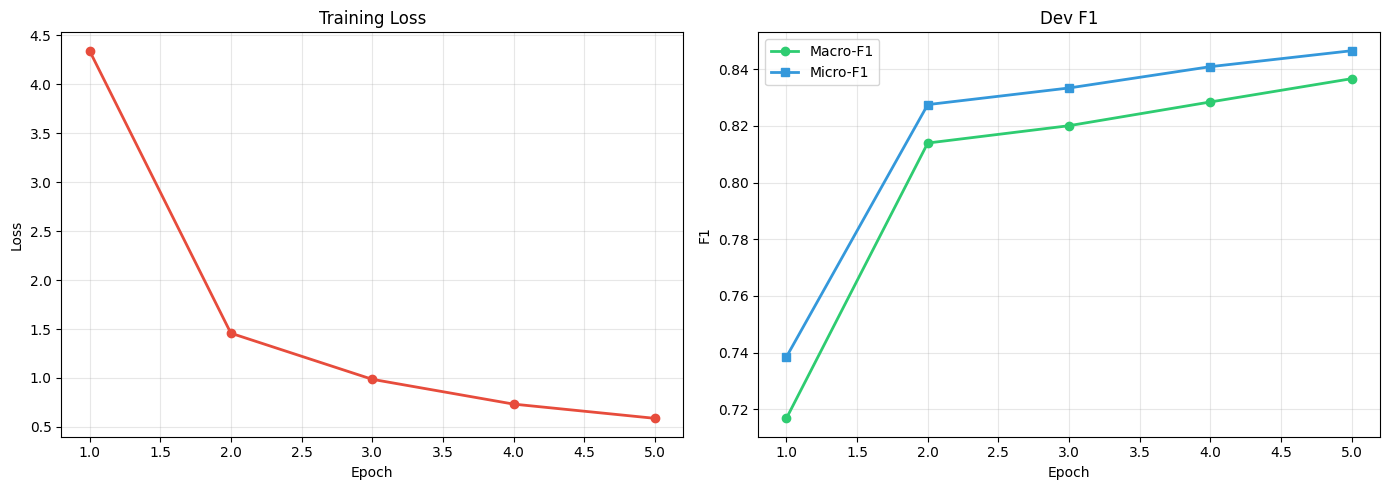

In [19]:

import matplotlib.pyplot as plt
import pandas as pd

if all_histories:
    hist = all_histories[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(range(1, len(hist["train_loss"])+1), hist["train_loss"], 'o-', color='#e74c3c', lw=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Training Loss"); axes[0].grid(alpha=0.3)
    
    axes[1].plot(range(1, len(hist["dev_macro_f1"])+1), hist["dev_macro_f1"], 'o-', color='#2ecc71', lw=2, label='Macro-F1')
    axes[1].plot(range(1, len(hist["dev_micro_f1"])+1), hist["dev_micro_f1"], 's-', color='#3498db', lw=2, label='Micro-F1')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1"); axes[1].set_title("Dev F1"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), bbox_inches="tight")
    plt.show()


In [22]:

def predict_entities(text, model, tokenizer, device):
    model.eval()
    words = text.split()
    
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        max_length=MAX_SEQ_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    
    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)
    word_ids = encoding.word_ids(batch_index=0)
    
    target_word_indices = []
    prev_word_id = None
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != prev_word_id:
            target_word_indices.append(idx)
        prev_word_id = word_id
        
    target_word_mask = [True] * len(target_word_indices)
    
    t_ids = ids
    t_mask = mask
    t_target_word_indices = torch.tensor([target_word_indices], dtype=torch.long).to(device)
    t_target_word_mask = torch.tensor([target_word_mask], dtype=torch.bool).to(device)
    
    with torch.no_grad():
        preds = model(t_ids, t_mask, t_target_word_indices, t_target_word_mask)
        
    pred_ids = preds[0]
    results = []
    for w, p_id in zip(words, pred_ids):
        results.append((w, ID2LABEL.get(p_id, "O")))
    return results

model = SAILNER(num_labels=NUM_LABELS).to(device)
ckpt_path = os.path.join(SAVE_DIR, "sail_ner_fold_0.pt")
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only = False)
    model.load_state_dict(ckpt["model_state_dict"])
    
demos = [
    "The petitioner Rajesh Kumar filed a writ petition under Article 226 of the Constitution in the High Court of Delhi",
    "In the case of State of Maharashtra vs Mohd Yakub 1980 AIR 1111 the Supreme Court held that Section 302 of IPC applies",
    "Justice D.Y. Chandrachud delivered the judgment on 15th March 2023 in New Delhi",
]
print("SAIL-NER Inference Demo\n" + "=" * 60)
for text in demos:
    print(f"\nInput: {text}")
    for w, l in predict_entities(text, model, tokenizer, device):
        if l != "O":
            print(f"  {l:20s} -> {w}")
print("\nDone!")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: evolawyer/inlegalbert-sc-ner-silver
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


SAIL-NER Inference Demo

Input: The petitioner Rajesh Kumar filed a writ petition under Article 226 of the Constitution in the High Court of Delhi
  B-PETITIONER         -> Rajesh
  I-PETITIONER         -> Kumar
  B-PROVISION          -> Article
  I-PROVISION          -> 226
  B-STATUTE            -> Constitution
  B-COURT              -> High
  I-COURT              -> Court
  I-COURT              -> of
  I-COURT              -> Delhi

Input: In the case of State of Maharashtra vs Mohd Yakub 1980 AIR 1111 the Supreme Court held that Section 302 of IPC applies
  B-PRECEDENT          -> State
  I-PRECEDENT          -> of
  I-PRECEDENT          -> Maharashtra
  I-PRECEDENT          -> vs
  I-PRECEDENT          -> Mohd
  I-PRECEDENT          -> Yakub
  I-PRECEDENT          -> 1980
  I-PRECEDENT          -> AIR
  I-PRECEDENT          -> 1111
  B-COURT              -> Supreme
  I-COURT              -> Court
  B-PROVISION          -> Section
  I-PROVISION          -> 302
  B-STATUTE          